# 🔗 DataCo Smart Supply Chain — Phase 1
## Fraud Order Analysis + Market Segmentation

**Dataset**: DataCo Smart Supply Chain for Big Data Analysis  
**Author**: Operations Analytics Capstone  
**Objective**: Identify fraud patterns and segment markets by value/risk to create a clean baseline for optimization phases.

---

### Phase 1 Steps:
1. **P0 — Data Quality Check**: Load, validate, clean
2. **P1 — Fraud Order Analysis**: Profile fraud vs non-fraud at order-level
3. **P2 — Market Segmentation**: Market × Customer Segment scorecard with risk tiers

### Output Contract:
| # | Table | Description |
|---|-------|-------------|
| 1 | `fraud_profile_order_level` | Fraud rate by Type/Market/Segment combinations |
| 2 | `market_segment_scorecard` | Revenue, profit, late rate by Market × Segment |
| 3 | `clean_baseline_df` | Filtered data for Phase 2/3 (excl CANCELED + SUSPECTED_FRAUD) |

## 📦 Setup & Imports

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
plt.rcParams.update({
    'figure.figsize': (12, 7),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120,
})
sns.set_style("whitegrid")

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


---
# 📊 P0 — Load Data & Data Quality Check

**Key Rules:**
- Encoding: `latin-1` (NOT UTF-8)
- Grain: **item-level** (1 row = 1 product in 1 order)
- Drop PII columns before analysis

In [83]:
# ─── LOAD DATA ──────────────────────────────────────────────────────
# BẮT BUỘC dùng encoding='latin-1' (file CSV dùng Latin-1, không phải UTF-8)
# Nếu chạy trên Kaggle:
# df = pd.read_csv('/kaggle/input/dataco-smart-supply-chain-for-big-data-analysis/DataCoSupplyChainDataset.csv', encoding='latin-1')

df = pd.read_csv('E:/PROJECT/01_Data_Analytics/Operation Analytics/DataCo SMART SUPPLY CHAIN FOR BIG DATA ANALYSIS/Data/DataCoSupplyChainDataset.csv', encoding='latin-1')
print(f"✅ Data loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

✅ Data loaded: 180,519 rows × 53 columns


### Missing Values Analysis

In [84]:
# ─── MISSING VALUES ─────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
}).sort_values('Missing %', ascending=False)

# Hiển thị các cột có missing values
has_missing = missing_df[missing_df['Missing Count'] > 0]
if len(has_missing) > 0:
    print("Columns with missing values:")
    display(has_missing.reset_index(drop=True))
    
    # Cảnh báo cột > 5% null
    high_missing = has_missing[has_missing['Missing %'] > 5]
    if len(high_missing) > 0:
        print(f"\n⚠️  Columns with > 5% missing: {list(high_missing['Column'])}")
else:
    print("✅ No missing values found")

Columns with missing values:


,Column,Missing Count,Missing %
0,Product Description,180519,100.00
1,Order Zipcode,155679,86.24
2,Customer Lname,8,0.00
3,Customer Zipcode,3,0.00



⚠️  Columns with > 5% missing: ['Product Description', 'Order Zipcode']


### Grain Verification & Duplicates

In [85]:
# ─── DUPLICATES & GRAIN CHECK ─────────────────────────────────────
dup_item_id = df['Order Item Id'].duplicated().sum()
print(f"Duplicate Order Item Id: {dup_item_id:,}")

# Kiểm tra grain: trung bình rows per Order Id
rows_per_order = df.groupby('Order Id').size()
print(f"\nGrain verification (item-level):")
print(f"  Total unique Order Ids: {df['Order Id'].nunique():,}")
print(f"  Total rows: {len(df):,}")
print(f"  Avg rows per Order Id: {rows_per_order.mean():.2f}")
print(f"  Min / Max rows per Order: {rows_per_order.min()} / {rows_per_order.max()}")
print(f"  ✅ Grain = ITEM-LEVEL confirmed (1 row = 1 product in 1 order)")

Duplicate Order Item Id: 0

Grain verification (item-level):
  Total unique Order Ids: 65,752
  Total rows: 180,519
  Avg rows per Order Id: 2.75
  Min / Max rows per Order: 1 / 5
  ✅ Grain = ITEM-LEVEL confirmed (1 row = 1 product in 1 order)


### Datetime Parsing

In [86]:
# ─── PARSE DATETIME ──────────────────────────────────────────────────
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])

print(f"Order date range:    {df['order date (DateOrders)'].min()} → {df['order date (DateOrders)'].max()}")
print(f"Shipping date range: {df['shipping date (DateOrders)'].min()} → {df['shipping date (DateOrders)'].max()}")

Order date range:    2015-01-01 00:00:00 → 2018-01-31 23:38:00
Shipping date range: 2015-01-03 00:00:00 → 2018-02-06 22:14:00


### Key Categorical Distributions

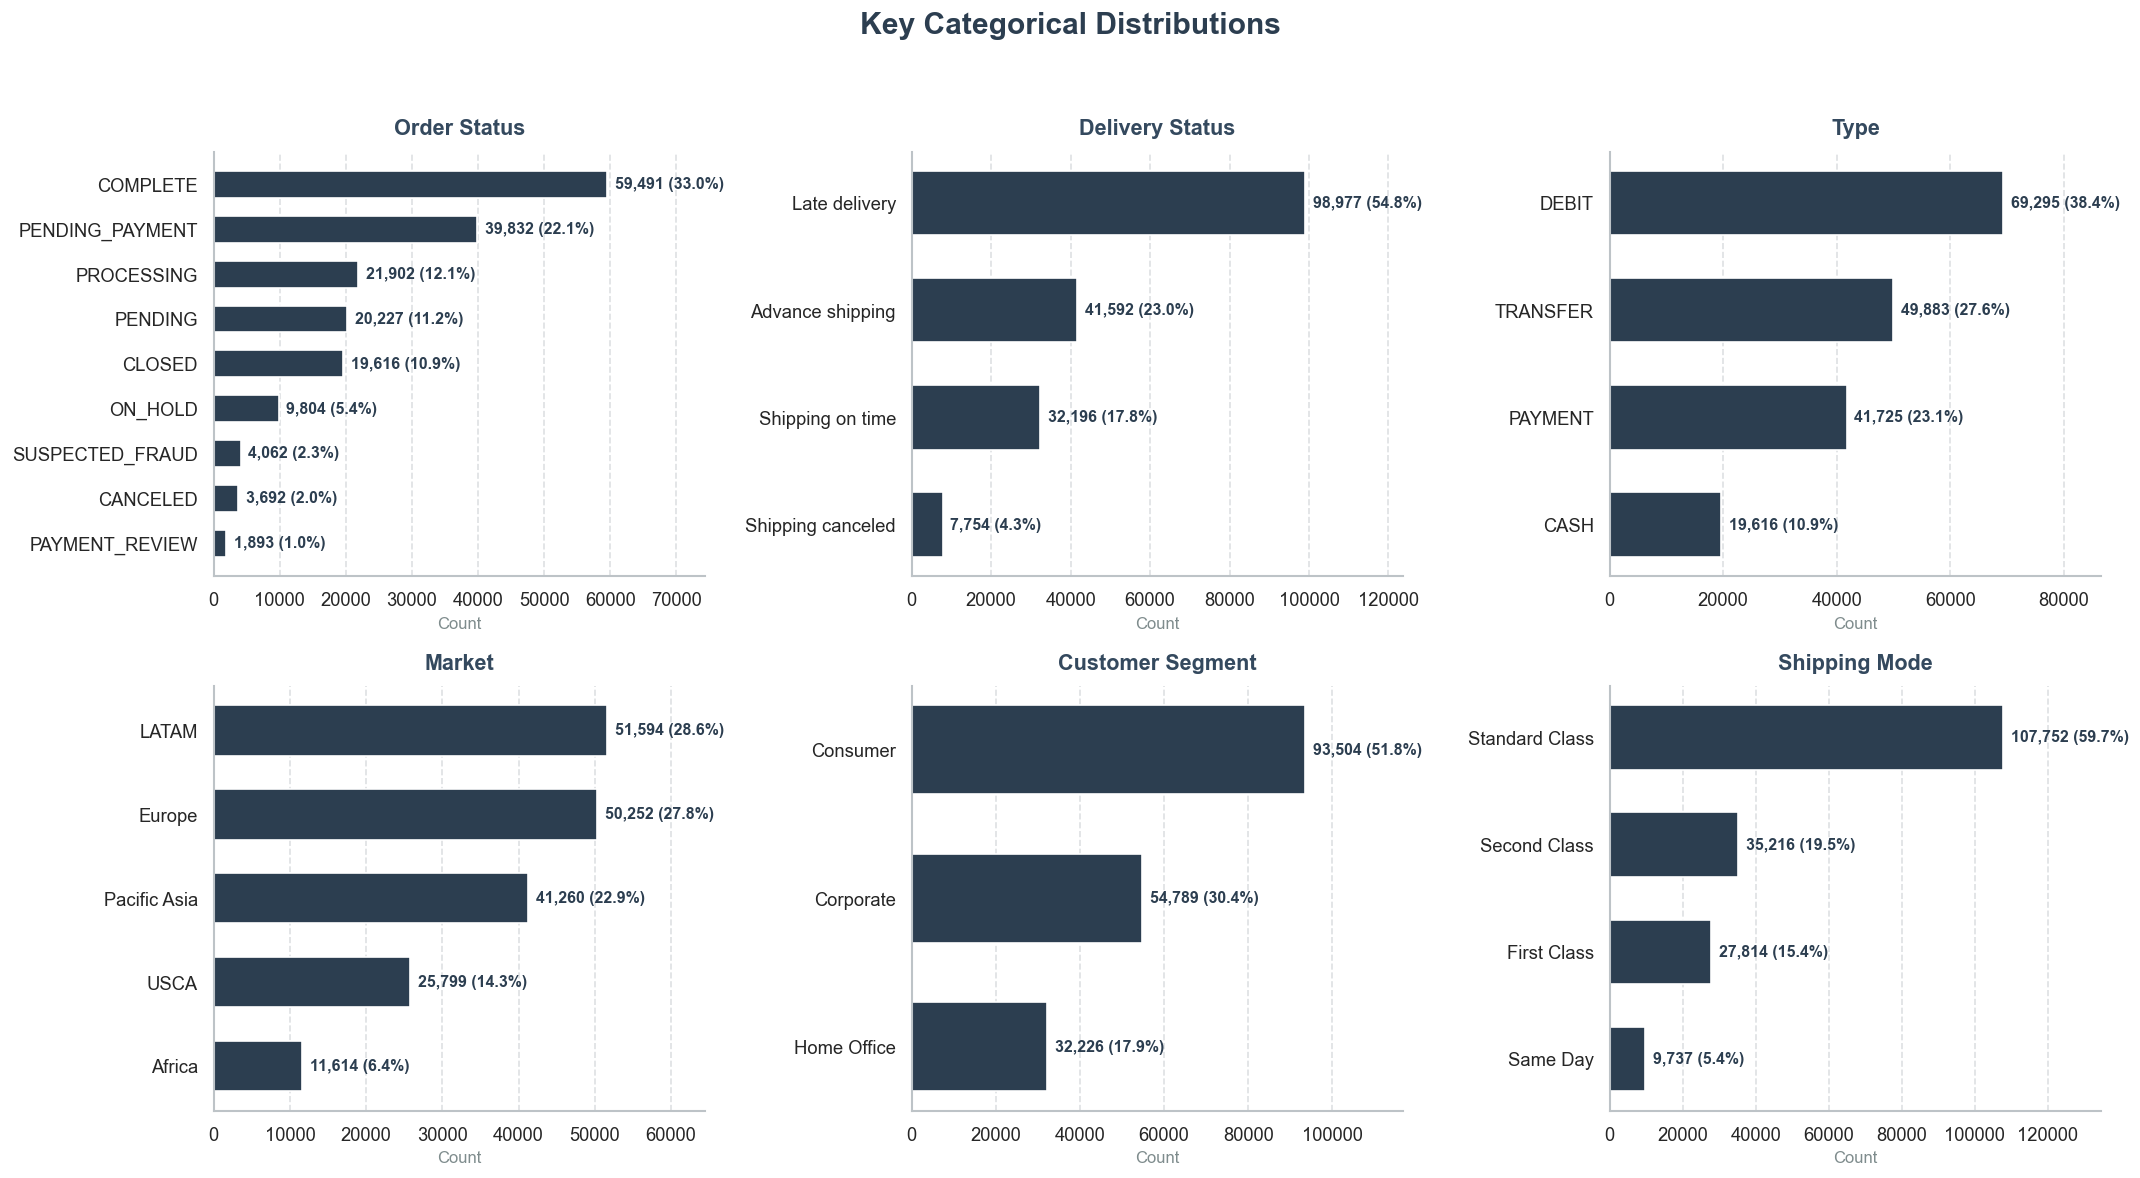

In [87]:
# ─── PHÂN PHỐI CÁC BIẾN PHÂN LOẠI QUAN TRỌNG ────────────────────────

sns.set_theme(style='white') 

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Key Categorical Distributions', fontsize=18, fontweight='bold', y=0.98, color='#2c3e50')

# Danh sách các cột cần vẽ
columns = ['Order Status', 'Delivery Status', 'Type', 'Market', 'Customer Segment', 'Shipping Mode']

for ax, col in zip(axes.flat, columns):
    vc = df[col].value_counts()
    
    # Sử dụng 1 tông màu tối giản, chuyên nghiệp (Thay #2c3e50 bằng màu thương hiệu nếu muốn)
    bars = ax.barh(vc.index, vc.values, color='#2c3e50', edgecolor='white', height=0.6)
    
    ax.set_title(col, fontweight='bold', fontsize=13, pad=10, color='#34495e')
    ax.set_xlabel('Count', fontsize=10, color='#7f8c8d')
    
    # 1. ĐẢO NGƯỢC TRỤC Y: Để danh mục lớn nhất lên TRÊN CÙNG
    ax.invert_yaxis()
    
    # 2. NỚI RỘNG TRỤC X: Tránh việc chữ định dạng (%) bị tràn hoặc cắt mất
    ax.set_xlim(0, max(vc.values) * 1.25)
    
    # 3. THÊM NHÃN DỮ LIỆU (Định dạng lại khoảng cách cho thoáng)
    total_samples = len(df)
    for bar, val in zip(bars, vc.values):
        pct = (val / total_samples) * 100
        ax.text(bar.get_width() + max(vc.values) * 0.02, 
                bar.get_y() + bar.get_height()/2,
                f'{val:,} ({pct:.1f}%)', 
                va='center', ha='left', fontsize=9.5, fontweight='semibold', color='#2c3e50')
    
    # 4. TINH CHỈNH KHUNG VIỀN (Ẩn các đường Spines không cần thiết)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#bdc3c7')
    ax.spines['bottom'].set_color('#bdc3c7')
    
    # 5. THÊM LƯỚI ĐỨNG MỜ (Giúp người vận hành dễ ước lượng)
    ax.xaxis.grid(True, linestyle='--', alpha=0.5, color='#bdc3c7')
    ax.set_axisbelow(True)  # Đẩy đường lưới ra phía sau các thanh bar

# Căn chỉnh layout không để đè chữ với suptitle
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Drop PII Columns & Summary Statistics

In [88]:
# ─── DROP CỘT PII / KHÔNG DÙNG ──────────────────────────────────────
pii_cols = [
    'Customer Email', 'Customer Fname', 'Customer Lname',
    'Customer Password', 'Product Description', 'Product Image',
    'Order Zipcode'
]
existing_pii = [c for c in pii_cols if c in df.columns]
df.drop(columns=existing_pii, inplace=True)
print(f"Dropped {len(existing_pii)} PII/unused columns")
print(f"Remaining shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dropped 7 PII/unused columns
Remaining shape: 180,519 rows × 46 columns


In [89]:
# ─── TÓM TẮT THỐNG KÊ SỐ ────────────────────────────────────────────
key_numeric = [
    'Sales', 'Order Item Total', 'Order Profit Per Order',
    'Benefit per order', 'Order Item Profit Ratio',
    'Order Item Discount', 'Order Item Discount Rate',
    'Order Item Product Price', 'Order Item Quantity',
    'Days for shipping (real)', 'Days for shipment (scheduled)', 'Late_delivery_risk'
]
summary = df[key_numeric].describe().T[['mean', 'std', 'min', '25%', '50%', '75%', 'max']]

# 1. Định nghĩa bộ định dạng số theo đúng bản chất của từng hàng
row_formats = {
    'Sales': '${:,.2f}',
    'Order Item Total': '${:,.2f}',
    'Order Profit Per Order': '${:,.2f}',
    'Benefit per order': '${:,.2f}',
    'Order Item Profit Ratio': '{:.1%}',      # Chuyển số thập phân sang %
    'Order Item Discount': '${:,.2f}',
    'Order Item Discount Rate': '{:.1%}',     # Chuyển số thập phân sang %
    'Order Item Product Price': '${:,.2f}',
    'Order Item Quantity': '{:,.1f}',
    'Days for shipping (real)': '{:,.1f}',
    'Days for shipment (scheduled)': '{:,.1f}',
    'Late_delivery_risk': '{:,.2f}'
}

# 2. Khởi tạo Styler và duyệt qua từng dòng để gán định dạng số
styler_summary = summary.style

for feature, fmt in row_formats.items():
    if feature in styler_summary.index:
        styler_summary = styler_summary.format(fmt, subset=pd.IndexSlice[feature, :])

# Hiển thị bảng kết quả sạch sẽ
display(styler_summary)

,mean,std,min,25%,50%,75%,max
Sales,$203.77,$132.27,$9.99,$119.98,$199.92,$299.95,"$1,999.99"
Order Item Total,$183.11,$120.04,$7.49,$104.38,$163.99,$247.40,"$1,939.99"
Order Profit Per Order,$21.97,$104.43,"$-4,274.98",$7.00,$31.52,$64.80,$911.80
Benefit per order,$21.97,$104.43,"$-4,274.98",$7.00,$31.52,$64.80,$911.80
Order Item Profit Ratio,12.1%,46.7%,-275.0%,8.0%,27.0%,36.0%,50.0%
Order Item Discount,$20.66,$21.80,$0.00,$5.40,$14.00,$29.99,$500.00
Order Item Discount Rate,10.2%,7.0%,0.0%,4.0%,10.0%,16.0%,25.0%
Order Item Product Price,$141.23,$139.73,$9.99,$50.00,$59.99,$199.99,"$1,999.99"
Order Item Quantity,2.1,1.5,1.0,1.0,1.0,3.0,5.0
Days for shipping (real),3.5,1.6,0.0,2.0,3.0,5.0,6.0


### P0 Summary

| Metric | Value |
|--------|-------|
| Rows | 180,519 |
| Columns (after PII drop) | 46 |
| Grain | Item-level |
| Unique Orders | 65,752 |
| Avg items/order | 2.75 |
| Date range | 2015-01-01 to 2018-01-31 |
| Duplicate Order Item Id | 0 |

> ✅ **P0 Complete** — Data loaded, validated, PII dropped, grain confirmed.

---
# 🔍 P1 — Fraud Order Analysis

**Key Rules:**
- **DO NOT** filter out SUSPECTED_FRAUD — it's the label we're analyzing
- Calculate fraud at **order-level** (group by Order Id first)
- Order Status is the **label**, NOT a feature

In [90]:
# ─── TẠO FRAUD FLAG ─────────────────────────────────────────────────
# fraud_flag = 1 nếu Order Status == 'SUSPECTED_FRAUD', ngược lại = 0
df['fraud_flag'] = (df['Order Status'] == 'SUSPECTED_FRAUD').astype(int)

print(f"Fraud flag distribution (item-level):")
print(f"  Non-fraud: {(df['fraud_flag']==0).sum():,}")
print(f"  Fraud:     {(df['fraud_flag']==1).sum():,}")
print(f"  Fraud rate (item): {df['fraud_flag'].mean()*100:.2f}%")

Fraud flag distribution (item-level):


  Non-fraud: 176,457
  Fraud:     4,062
  Fraud rate (item): 2.25%


In [91]:
# ─── DEDUPLICATE SANG ORDER-LEVEL ─────────────────────────────────────
# Aggregate metrics từ item-level lên order-level
# Lưu ý: Order Profit Per Order bị lặp trên mỗi item row → lấy first() để tránh SUM sai
order_df = df.groupby('Order Id').agg(
    fraud_flag=('fraud_flag', 'max'),
    Type=('Type', 'first'),
    Market=('Market', 'first'),
    Customer_Segment=('Customer Segment', 'first'),
    Category_Name=('Category Name', 'first'),
    total_sales=('Sales', 'sum'),
    order_profit=('Order Profit Per Order', 'first'),  # Tránh double-count!
    avg_discount_rate=('Order Item Discount Rate', 'mean'),
    avg_profit_ratio=('Order Item Profit Ratio', 'mean'),
    late_delivery_risk=('Late_delivery_risk', 'max'),
    n_items=('Order Item Id', 'count'),
    total_quantity=('Order Item Quantity', 'sum'),
    shipping_days=('Days for shipping (real)', 'first'),
).reset_index()

print(f"✅ Order-level DataFrame: {len(order_df):,} orders")
print(f"   Fraud orders: {order_df['fraud_flag'].sum():,} ({order_df['fraud_flag'].mean()*100:.2f}%)")
print(f"   Non-fraud orders: {(order_df['fraud_flag']==0).sum():,}")

✅ Order-level DataFrame: 65,752 orders
   Fraud orders: 1,488 (2.26%)
   Non-fraud orders: 64,264


### Fraud Rate by Dimension

In [92]:
# ─── FRAUD RATE THEO CÁC CHIỀU ───────────────────────────────────────
def fraud_rate_by(col, display_name):
    result = order_df.groupby(col).agg(
        order_count=('fraud_flag', 'count'),
        fraud_count=('fraud_flag', 'sum'),
        fraud_rate=('fraud_flag', 'mean'),
        avg_discount_rate=('avg_discount_rate', 'mean'),
        avg_sales=('total_sales', 'mean'),
        avg_profit_ratio=('avg_profit_ratio', 'mean'),
        late_rate=('late_delivery_risk', 'mean'),
    ).reset_index()
    result['fraud_rate_pct'] = result['fraud_rate'] * 100
    result = result.sort_values('fraud_rate', ascending=False)
    print(f"\n{display_name}:")
    return result

fraud_formats = {
    'fraud_rate_pct': '{:.2f}%',      # Đã nhân 100 ở hàm trên, gán thêm đuôi %
    'order_count': '{:,}',            # Phân tách hàng nghìn cho số lượng đơn
    'avg_discount_rate': '{:.1%}',     # Số thập phân sang % mượt mà
    'avg_sales': '${:,.2f}'           # Định dạng tiền tệ $
}

# 1. Fraud Rate by Payment Type
fraud_by_type = fraud_rate_by('Type', 'Fraud Rate by Payment Type')
df_type_disp = fraud_by_type[['Type', 'fraud_rate_pct', 'order_count', 'avg_discount_rate', 'avg_sales']]
display(df_type_disp.style.format({k: v for k, v in fraud_formats.items() if k in df_type_disp.columns}))

# 2. Fraud Rate by Market
fraud_by_market = fraud_rate_by('Market', 'Fraud Rate by Market')
df_market_disp = fraud_by_market[['Market', 'fraud_rate_pct', 'order_count', 'avg_sales']]
display(df_market_disp.style.format({k: v for k, v in fraud_formats.items() if k in df_market_disp.columns}))

# 3. Fraud Rate by Customer Segment
fraud_by_segment = fraud_rate_by('Customer_Segment', 'Fraud Rate by Customer Segment')
df_segment_disp = fraud_by_segment[['Customer_Segment', 'fraud_rate_pct', 'order_count']]
display(df_segment_disp.style.format({k: v for k, v in fraud_formats.items() if k in df_segment_disp.columns}))


Fraud Rate by Payment Type:


,Type,fraud_rate_pct,order_count,avg_discount_rate,avg_sales
3,TRANSFER,8.23%,"18,077",10.1%,$563.97
0,CASH,0.00%,"7,249",10.0%,$554.92
1,DEBIT,0.00%,"25,340",10.2%,$555.52
2,PAYMENT,0.00%,"15,086",10.2%,$562.80



Fraud Rate by Market:


,Market,fraud_rate_pct,order_count,avg_sales
4,USCA,2.44%,"8,579",$590.57
2,LATAM,2.32%,"17,181",$598.20
1,Europe,2.30%,"18,561",$585.77
0,Africa,2.23%,"3,854",$595.34
3,Pacific Asia,2.10%,"17,577",$470.71



Fraud Rate by Customer Segment:


,Customer_Segment,fraud_rate_pct,order_count
0,Consumer,2.37%,"34,119"
2,Home Office,2.22%,"11,777"
1,Corporate,2.11%,"19,856"


### Fraud vs Non-Fraud Comparison

In [93]:
# ─── SO SÁNH FRAUD vs NON-FRAUD ──────────────────────────────────────
fraud = order_df[order_df['fraud_flag'] == 1]
non_fraud = order_df[order_df['fraud_flag'] == 0]

comparison_metrics = {
    'Avg Sales per Order': ('total_sales', 'mean'),
    'Avg Order Profit': ('order_profit', 'mean'),
    'Avg Profit Ratio': ('avg_profit_ratio', 'mean'),
    'Avg Discount Rate': ('avg_discount_rate', 'mean'),
    'Avg Items per Order': ('n_items', 'mean'),
    'Avg Total Quantity': ('total_quantity', 'mean'),
    'Late Delivery Rate': ('late_delivery_risk', 'mean'),
    'Avg Shipping Days': ('shipping_days', 'mean'),
}

comp_rows = []
for metric_name, (col, agg_func) in comparison_metrics.items():
    fraud_val = getattr(fraud[col], agg_func)()
    non_fraud_val = getattr(non_fraud[col], agg_func)()
    lift = ((fraud_val - non_fraud_val) / abs(non_fraud_val)) * 100 if non_fraud_val != 0 else 0
    comp_rows.append({
        'Metric': metric_name,
        'Fraud': round(fraud_val, 3),
        'Non-Fraud': round(non_fraud_val, 3),
        'Lift %': round(lift, 1)
    })

metric_formats = {
    'Avg Sales per Order': '${:,.2f}',
    'Avg Order Profit': '${:,.2f}',
    'Avg Profit Ratio': '{:.1%}',       # Số thập phân sang %
    'Avg Discount Rate': '{:.1%}',      # Số thập phân sang %
    'Avg Items per Order': '{:,.2f}',
    'Avg Total Quantity': '{:,.1f}',
    'Late Delivery Rate': '{:.1%}',     # Số thập phân sang %
    'Avg Shipping Days': '{:,.1f}'
}

# 2. KHỞI TẠO STYLER VÀ ĐỊNH DẠNG ROW-BY-ROW
styler_comp = comparison_df.style

for metric, fmt in metric_formats.items():
    # Xác định đúng vị trí dòng dựa trên tên Metric
    row_idx = comparison_df[comparison_df['Metric'] == metric].index
    if not row_idx.empty:
        styler_comp = styler_comp.format(fmt, subset=pd.IndexSlice[row_idx, ['Fraud', 'Non-Fraud']])

# 3. ĐỊNH DẠNG RIÊNG CỘT LIFT % (Hiển thị dấu + trước số dương cho chuẩn báo cáo)
styler_comp = styler_comp.format('{:+.1f}%', subset=['Lift %'])

# Hiển thị bảng kết quả sạch thoáng
display(styler_comp)

,Metric,Fraud,Non-Fraud,Lift %
0,Avg Sales per Order,$555.06,$559.55,-0.8%
1,Avg Order Profit,$24.29,$21.05,+15.4%
2,Avg Profit Ratio,11.1%,12.1%,-9.0%
3,Avg Discount Rate,10.2%,10.2%,+0.3%
4,Avg Items per Order,2.73,2.75,-0.6%
5,Avg Total Quantity,5.8,5.8,-0.9%
6,Late Delivery Rate,0.0%,56.1%,-100.0%
7,Avg Shipping Days,3.5,3.5,+0.2%


### Crosstab Analysis

In [94]:
# ─── CROSSTAB Type × fraud_flag ───────────────────────────────────────
ct_type = pd.crosstab(order_df['Type'], order_df['fraud_flag'], margins=True)
ct_type.columns = ['Non-Fraud', 'Fraud', 'Total']
ct_type['Fraud Rate %'] = (ct_type['Fraud'] / ct_type['Total'] * 100).round(2)
print("📊 Type × Fraud Flag:")
display(ct_type)

print()

# ─── CROSSTAB Market × fraud_flag ─────────────────────────────────────
ct_market = pd.crosstab(order_df['Market'], order_df['fraud_flag'], margins=True)
ct_market.columns = ['Non-Fraud', 'Fraud', 'Total']
ct_market['Fraud Rate %'] = (ct_market['Fraud'] / ct_market['Total'] * 100).round(2)
print("📊 Market × Fraud Flag:")
display(ct_type.style.format({
    'Non-Fraud': '{:,}',
    'Fraud': '{:,}',
    'Total': '{:,}',
    'Fraud Rate %': '{:.2f}%'
}))

print()

# ─── CROSSTAB Market × fraud_flag ─────────────────────────────────────
ct_market = pd.crosstab(order_df['Market'], order_df['fraud_flag'], margins=True)
ct_market.columns = ['Non-Fraud', 'Fraud', 'Total']
ct_market['Fraud Rate %'] = (ct_market['Fraud'] / ct_market['Total'] * 100).round(2)

print("📊 Market × Fraud Flag:")
# Áp dụng bộ format tương tự cho bảng Market
display(ct_market.style.format({
    'Non-Fraud': '{:,}',
    'Fraud': '{:,}',
    'Total': '{:,}',
    'Fraud Rate %': '{:.2f}%'
}))

📊 Type × Fraud Flag:


,Non-Fraud,Fraud,Total,Fraud Rate %
Type,,,,
CASH,7249,0,7249,0.00
DEBIT,25340,0,25340,0.00
PAYMENT,15086,0,15086,0.00
TRANSFER,16589,1488,18077,8.23
All,64264,1488,65752,2.26



📊 Market × Fraud Flag:


,Non-Fraud,Fraud,Total,Fraud Rate %
Type,,,,
CASH,"7,249",0,"7,249",0.00%
DEBIT,"25,340",0,"25,340",0.00%
PAYMENT,"15,086",0,"15,086",0.00%
TRANSFER,"16,589","1,488","18,077",8.23%
All,"64,264","1,488","65,752",2.26%



📊 Market × Fraud Flag:


,Non-Fraud,Fraud,Total,Fraud Rate %
Market,,,,
Africa,"3,768",86,"3,854",2.23%
Europe,"18,135",426,"18,561",2.30%
LATAM,"16,783",398,"17,181",2.32%
Pacific Asia,"17,208",369,"17,577",2.10%
USCA,"8,370",209,"8,579",2.44%
All,"64,264","1,488","65,752",2.26%


### Top 10 Highest Fraud Rate Combinations

In [95]:
# ─── TOP 10 TỔ HỢP FRAUD RATE CAO NHẤT ──────────────────────────────
combo = order_df.groupby(['Market', 'Type', 'Customer_Segment']).agg(
    order_count=('fraud_flag', 'count'),
    fraud_count=('fraud_flag', 'sum'),
    fraud_rate=('fraud_flag', 'mean'),
    avg_discount_rate=('avg_discount_rate', 'mean'),
    avg_sales=('total_sales', 'mean'),
    avg_profit_ratio=('avg_profit_ratio', 'mean'),
).reset_index()

# Lọc tổ hợp có ít nhất 30 orders để tránh noise
combo_filtered = combo[combo['order_count'] >= 30].copy()
combo_filtered['fraud_rate_pct'] = combo_filtered['fraud_rate'] * 100
combo_filtered = combo_filtered.sort_values('fraud_rate', ascending=False).reset_index(drop=True)

print("Top 10 Fraud Rate Combinations (min 30 orders):")
df_disp = combo_filtered.head(10)[['Market', 'Type', 'Customer_Segment', 'fraud_rate_pct', 'order_count', 'fraud_count']]

# Ép định dạng số sạch sẽ: Tỷ lệ hiển thị %, Số lượng đơn ra số nguyên phẳng có dấu phẩy
display(df_disp.style.format({
    'fraud_rate_pct': '{:.2f}%',
    'order_count': '{:,}',
    'fraud_count': '{:,}'
}))

Top 10 Fraud Rate Combinations (min 30 orders):


,Market,Type,Customer_Segment,fraud_rate_pct,order_count,fraud_count
0,USCA,TRANSFER,Consumer,9.31%,"1,246",116
1,USCA,TRANSFER,Home Office,9.09%,407,37
2,Europe,TRANSFER,Consumer,8.96%,"2,588",232
3,Africa,TRANSFER,Consumer,8.55%,550,47
4,LATAM,TRANSFER,Corporate,8.38%,"1,468",123
5,Pacific Asia,TRANSFER,Consumer,8.36%,"2,463",206
6,Europe,TRANSFER,Home Office,8.35%,874,73
7,LATAM,TRANSFER,Consumer,8.34%,"2,481",207
8,Europe,TRANSFER,Corporate,7.85%,"1,542",121
9,Pacific Asia,TRANSFER,Home Office,7.83%,869,68


### Fraud Visualizations

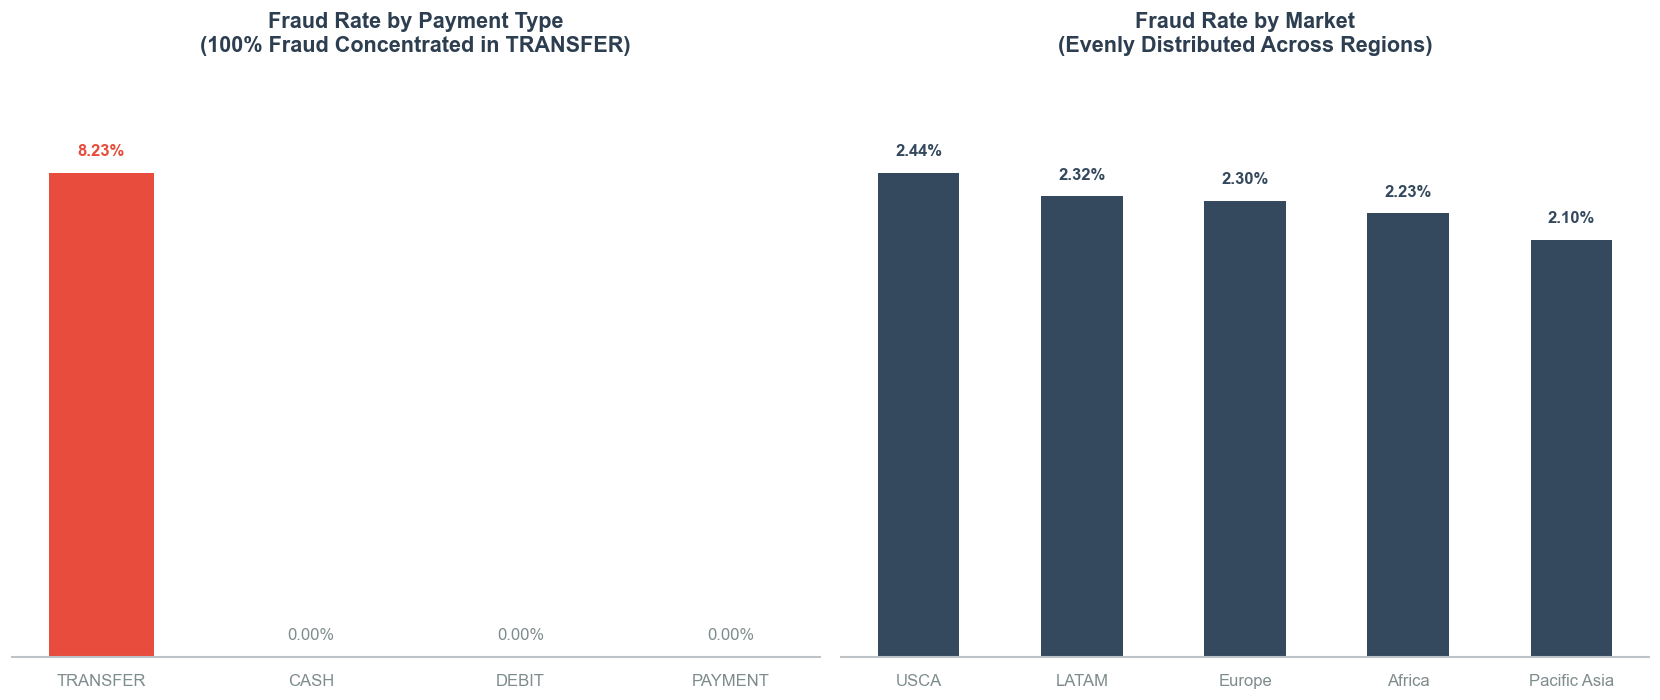

In [96]:
# ─── CHART 1: Fraud Rate by Type & Market ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Fraud rate by Type
ax = axes[0]
# SỬA LỖI LOGIC: Tự động tô đỏ nếu là TRANSFER, bất kể thứ tự dòng dữ liệu
colors = ['#E74C3C' if t == 'TRANSFER' else '#BDC3C7' for t in fraud_by_type['Type']]
bars = ax.bar(fraud_by_type['Type'], fraud_by_type['fraud_rate_pct'], color=colors, width=0.5, edgecolor='none')

ax.set_title('Fraud Rate by Payment Type\n(100% Fraud Concentrated in TRANSFER)', fontweight='bold', fontsize=13, color='#2C3E50', pad=15)

# TỐI ƯU UI/UX: Ẩn hoàn toàn trục Y và đường lưới vì đã có nhãn trực tiếp trên đầu cột
ax.get_yaxis().set_visible(False)
ax.tick_params(colors='#7F8C8D', labelsize=10, bottom=False)

# Loại bỏ viền thừa
for spine in ['top', 'right', 'left', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#BDC3C7')

# Thêm nhãn trực tiếp
max_val_t = fraud_by_type['fraud_rate_pct'].max()
for bar, val in zip(bars, fraud_by_type['fraud_rate_pct']):
    color = '#E74C3C' if val > 0 else '#7F8C8D'
    weight = 'bold' if val > 0 else 'normal'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val_t * 0.03,
            f'{val:.2f}%', ha='center', va='bottom', fontweight=weight, color=color, fontsize=10)
ax.set_ylim(0, max_val_t * 1.2)


# 2. Fraud rate by Market
ax = axes[1]
bars = ax.bar(fraud_by_market['Market'], fraud_by_market['fraud_rate_pct'], color='#34495E', width=0.5, edgecolor='none')

ax.set_title('Fraud Rate by Market\n(Evenly Distributed Across Regions)', fontweight='bold', fontsize=13, color='#2C3E50', pad=15)

# TỐI ƯU UI/UX: Ẩn hoàn toàn trục Y cho đồng bộ với Chart 1
ax.get_yaxis().set_visible(False)
ax.tick_params(colors='#7F8C8D', labelsize=10, bottom=False)

# Loại bỏ viền thừa
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#BDC3C7')

# Thêm nhãn trực tiếp
max_val_m = fraud_by_market['fraud_rate_pct'].max()
for bar, val in zip(bars, fraud_by_market['fraud_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val_m * 0.03,
            f'{val:.2f}%', ha='center', va='bottom', fontweight='semibold', color='#34495E', fontsize=10)
ax.set_ylim(0, max_val_m * 1.2)

plt.tight_layout()
plt.show()

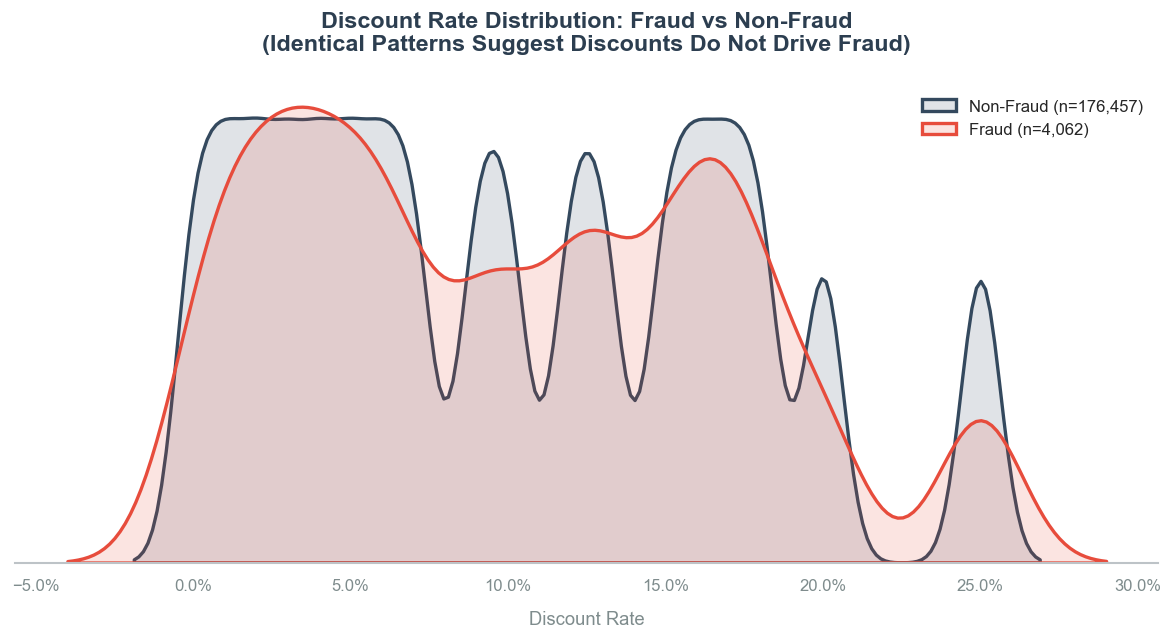

In [97]:
# ─── CHART 2: Discount Distribution Comparison ───────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))

df_fraud_disc = df[df['fraud_flag'] == 1]['Order Item Discount Rate']
df_nfraud_disc = df[df['fraud_flag'] == 0]['Order Item Discount Rate']

# 1. TỐI ƯU VISUAL: Sử dụng KDE mượt mà thay cho Histogram để tránh nhem nhuốc màu
sns.kdeplot(df_nfraud_disc, fill=True, color='#34495E', alpha=0.15, linewidth=2,
            label=f'Non-Fraud (n={len(df_nfraud_disc):,})', ax=ax)
sns.kdeplot(df_fraud_disc, fill=True, color='#E74C3C', alpha=0.15, linewidth=2,
            label=f'Fraud (n={len(df_fraud_disc):,})', ax=ax)

# Thiết lập tiêu đề cao cấp
ax.set_title('Discount Rate Distribution: Fraud vs Non-Fraud\n(Identical Patterns Suggest Discounts Do Not Drive Fraud)', 
             fontweight='bold', fontsize=14, color='#2C3E50', pad=20)
ax.set_xlabel('Discount Rate', fontsize=11, color='#7F8C8D', labelpad=10)

# 2. TỐI ƯU UI/UX: Định dạng trục X hiển thị dạng % (Tự động nhận diện nếu gốc là 0.1 -> 10%)
# Nếu dữ liệu gốc đã là 10, 20, 30... thì đổi thành mtick.PercentFormatter(xmax=100)
is_decimal = df_nfraud_disc.max() <= 1.0
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0 if is_decimal else 100.0))
ax.tick_params(axis='x', colors='#7F8C8D', labelsize=10)

# 3. TỐI ƯU UI/UX: Ẩn trục Y vì chỉ số Density không quá quan trọng với người vận hành bằng hình dáng đường cong
ax.get_yaxis().set_visible(False)

# Loại bỏ toàn bộ viền, chỉ giữ lại đường trục X phẳng tối giản
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#BDC3C7')

# Legend tùy chỉnh thanh lịch nằm gọn góc trên bên phải
ax.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

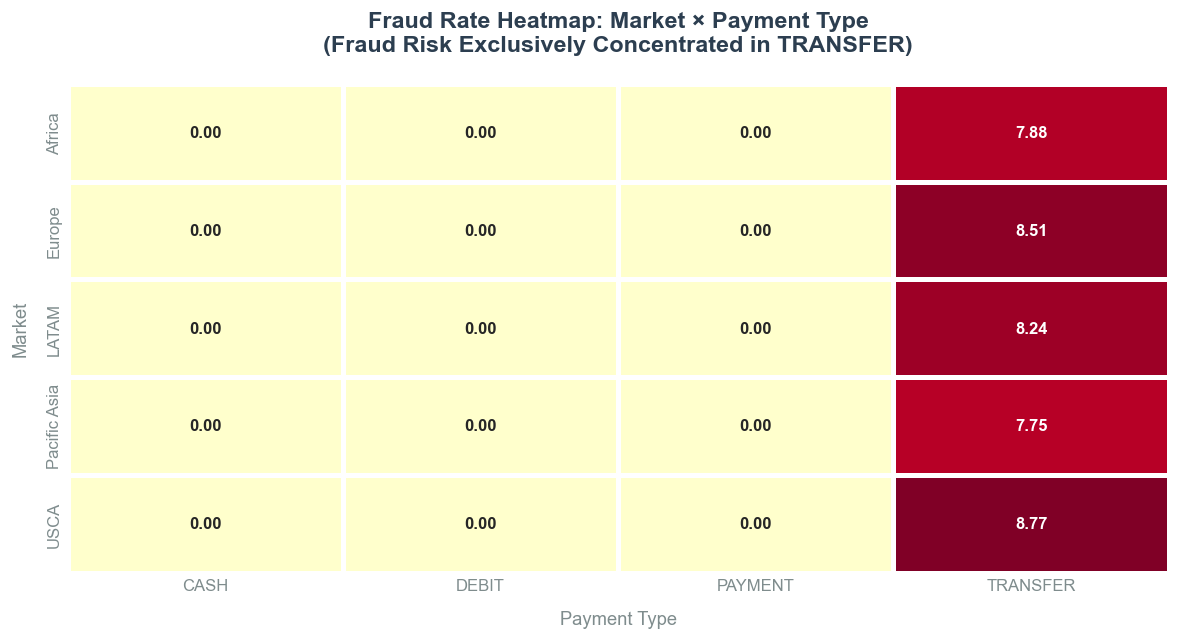

In [98]:
# ─── CHART 3: Fraud Heatmap (Market × Type) ──────────────────────────
pivot_fraud = order_df.groupby(['Market', 'Type'])['fraud_flag'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(10, 5.5))

# TỐI ƯU UI/UX:
# 1. cbar=False: Bỏ hẳn thanh màu bên phải để giải phóng không gian, giúp heatmap rộng rãi, dễ đọc.
# 2. Đổi sang 'YlOrRd' (Yellow-Orange-Red) hoặc 'Reds' để đẩy mạnh tính "cảnh báo rủi ro" của Fraud.
# 3. Tăng linewidths lên 2 để các ô tách biệt sạch sẽ như các khối dashboard.
sns.heatmap(pivot_fraud, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=2, linecolor='white', cbar=False,
            annot_kws={'fontsize': 10, 'weight': 'bold'})

# Tiêu đề phân cấp rõ ràng
ax.set_title('Fraud Rate Heatmap: Market × Payment Type\n(Fraud Risk Exclusively Concentrated in TRANSFER)', 
             fontweight='bold', fontsize=14, color='#2C3E50', pad=20)

ax.set_ylabel('Market', fontsize=11, color='#7F8C8D', labelpad=10)
ax.set_xlabel('Payment Type', fontsize=11, color='#7F8C8D', labelpad=10)

# 3. TỐI ƯU UI/UX: length=0 để giấu các vạch tick nhỏ, chỉ giữ lại nhãn chữ cho sạch thoáng
ax.tick_params(axis='both', which='both', length=0, colors='#7F8C8D', labelsize=10)

plt.tight_layout()
plt.show()

### P1 Key Findings

🔴 **Critical Discovery**: **100% of fraud orders use TRANSFER payment type** (8.23% fraud rate vs 0% for DEBIT/CASH/PAYMENT)

| Insight | Detail | Action |
|---------|--------|--------|
| Payment Type Risk | TRANSFER = 8.23% fraud rate (sole fraud channel) | Enhanced verification for TRANSFER payments |
| Market Concentration | USCA slightly higher (2.44%) but fraud spread evenly | Market-level screening less effective |
| Discount Pattern | Minimal difference in discount rates | Discount not a strong fraud indicator |

**Fraud Handling Rules for Phase 2/3:**
1. Exclude `SUSPECTED_FRAUD` + `CANCELED` from demand baseline
2. Baseline fraud rate (2.26%) usable as penalty coefficient
3. All fraud = TRANSFER → strongest rule-based flag

In [99]:
# ─── TẠO fraud_profile_order_level TABLE (Output Contract) ────────────
fraud_profile = combo_filtered[['Market', 'Type', 'Customer_Segment', 
                                 'fraud_rate_pct', 'order_count',
                                 'avg_discount_rate', 'avg_sales', 
                                 'avg_profit_ratio']].copy()
fraud_profile.columns = ['Market', 'Type', 'Customer Segment', 'fraud_rate',
                          'order_count', 'avg_discount_rate', 'avg_sales_per_order',
                          'avg_profit_ratio']
fraud_profile = fraud_profile.sort_values('fraud_rate', ascending=False).reset_index(drop=True)
print(f"✅ fraud_profile_order_level: {len(fraud_profile)} rows")
df_disp = fraud_profile.head(10)

# TỐI ƯU: Ép định dạng số gọn gàng chuẩn Enterprise
display(df_disp.style.format({
    'fraud_rate': '{:.2f}%',
    'order_count': '{:,}',
    'avg_discount_rate': '{:.1%}',
    'avg_sales_per_order': '${:,.2f}',
    'avg_profit_ratio': '{:.1%}'
}))

✅ fraud_profile_order_level: 60 rows


,Market,Type,Customer Segment,fraud_rate,order_count,avg_discount_rate,avg_sales_per_order,avg_profit_ratio
0,USCA,TRANSFER,Consumer,9.31%,"1,246",10.0%,$589.86,12.9%
1,USCA,TRANSFER,Home Office,9.09%,407,10.0%,$580.45,13.1%
2,Europe,TRANSFER,Consumer,8.96%,"2,588",10.1%,$594.92,11.2%
3,Africa,TRANSFER,Consumer,8.55%,550,10.2%,$573.63,13.8%
4,LATAM,TRANSFER,Corporate,8.38%,"1,468",10.3%,$615.37,13.0%
5,Pacific Asia,TRANSFER,Consumer,8.36%,"2,463",10.2%,$482.85,10.4%
6,Europe,TRANSFER,Home Office,8.35%,874,10.1%,$582.00,10.3%
7,LATAM,TRANSFER,Consumer,8.34%,"2,481",10.2%,$600.80,12.0%
8,Europe,TRANSFER,Corporate,7.85%,"1,542",10.1%,$590.30,11.9%
9,Pacific Asia,TRANSFER,Home Office,7.83%,869,10.0%,$473.11,13.6%


---
# 📈 P2 — Market Segmentation

**Key Rules:**
- Baseline excludes `CANCELED` and `SUSPECTED_FRAUD`
- Revenue = `SUM(Sales)` at item-level
- Profit = `SUM(Order Profit Per Order)` **after deduplication by Order Id** (avoid double-count!)
- Order count = `COUNT DISTINCT(Order Id)`

In [100]:
# ─── CLEAN BASELINE ──────────────────────────────────────────────────
# Loại CANCELED và SUSPECTED_FRAUD theo quy tắc GEMINI.md
excluded_status = ['CANCELED', 'SUSPECTED_FRAUD']
clean_df = df[~df['Order Status'].isin(excluded_status)].copy()

print(f"✅ Full data: {len(df):,} rows")
print(f"✅ Clean baseline: {len(clean_df):,} rows")
print(f"   Removed: {len(df) - len(clean_df):,} rows ({(len(df) - len(clean_df))/len(df)*100:.1f}%)")

✅ Full data: 180,519 rows
✅ Clean baseline: 172,765 rows
   Removed: 7,754 rows (4.3%)


In [101]:
# ─── TÍNH METRICS THEO MARKET × CUSTOMER SEGMENT ─────────────────────
# Revenue ở item-level (SUM Sales)
revenue_df = clean_df.groupby(['Market', 'Customer Segment']).agg(
    revenue=('Sales', 'sum'),
    avg_discount_rate=('Order Item Discount Rate', 'mean'),
    late_delivery_rate=('Late_delivery_risk', 'mean'),
    avg_shipping_days=('Days for shipping (real)', 'mean'),
).reset_index()

# Order count và Profit ở order-level (deduplicate)
# Order Profit Per Order bị lặp trên mỗi item row → lấy first() per Order Id
order_level = clean_df.groupby(['Order Id', 'Market', 'Customer Segment']).agg(
    order_profit=('Order Profit Per Order', 'first'),  # Tránh double-count!
    order_sales=('Sales', 'sum'),
).reset_index()

order_metrics = order_level.groupby(['Market', 'Customer Segment']).agg(
    order_count=('Order Id', 'count'),
    total_profit=('order_profit', 'sum'),
    avg_order_value=('order_sales', 'mean'),
).reset_index()

# Merge
scorecard = revenue_df.merge(order_metrics, on=['Market', 'Customer Segment'])
scorecard['profit_margin'] = (scorecard['total_profit'] / scorecard['revenue'] * 100).round(2)
scorecard = scorecard.sort_values('revenue', ascending=False).reset_index(drop=True)
scorecard_disp = scorecard[['Market', 'Customer Segment', 'revenue', 'order_count', 
                             'avg_order_value', 'profit_margin', 'late_delivery_rate', 
                             'avg_discount_rate']]

display(scorecard_disp.style.format({
    'revenue': lambda x: f"${x/1e6:.2f}M",
    'order_count': '{:,}',
    'avg_order_value': '${:,.2f}',
    'profit_margin': '{:.2f}%',          # Đã nhân 100 ở trên, gán thêm đuôi %
    'late_delivery_rate': '{:.1%}',      # Số thập phân sang %
    'avg_discount_rate': '{:.1%}'        # Số thập phân sang %
}))

,Market,Customer Segment,revenue,order_count,avg_order_value,profit_margin,late_delivery_rate,avg_discount_rate
0,Europe,Consumer,$5.42M,"9,220",$587.86,4.26%,58.2%,10.2%
1,LATAM,Consumer,$5.06M,"8,487",$596.23,3.12%,57.1%,10.1%
2,Pacific Asia,Consumer,$4.10M,"8,684",$472.32,4.70%,56.9%,10.2%
3,Europe,Corporate,$3.17M,"5,380",$589.30,4.25%,56.5%,10.1%
4,LATAM,Corporate,$3.00M,"4,946",$605.74,3.63%,56.4%,10.2%
5,USCA,Consumer,$2.54M,"4,299",$591.02,3.29%,56.7%,10.2%
6,Pacific Asia,Corporate,$2.43M,"5,120",$474.24,4.15%,58.1%,10.2%
7,Europe,Home Office,$1.81M,"3,163",$573.76,3.35%,58.3%,10.3%
8,LATAM,Home Office,$1.77M,"2,981",$593.15,3.71%,57.1%,10.1%
9,USCA,Corporate,$1.44M,"2,450",$587.41,2.72%,58.0%,10.1%


### Segment Risk Tier Classification

In [102]:
# ─── SEGMENT RANKING ─────────────────────────────────────────────────
# Phân loại segment theo risk/value dựa trên median
pm_median = scorecard['profit_margin'].median()
lr_median = scorecard['late_delivery_rate'].median()
dr_median = scorecard['avg_discount_rate'].median()

def assign_tier(row):
    if row['profit_margin'] >= pm_median and row['late_delivery_rate'] <= lr_median:
        return 'High Value'
    elif row['late_delivery_rate'] > lr_median and row['profit_margin'] < pm_median:
        return 'High Risk'
    elif row['avg_discount_rate'] > dr_median:
        return 'Discount Sensitive'
    elif row['profit_margin'] >= pm_median:
        return 'Moderate Value'
    else:
        return 'Monitor'

scorecard['risk_tier'] = scorecard.apply(assign_tier, axis=1)

# Hiển thị tier summary
print("Segment Tier Summary:")
for tier in ['High Value', 'Moderate Value', 'Discount Sensitive', 'High Risk', 'Monitor']:
    tier_df = scorecard[scorecard['risk_tier'] == tier]
    if len(tier_df) > 0:
        tier_rev = tier_df['revenue'].sum()
        emoji = {'High Value': '🟢', 'Moderate Value': '🔵', 
                 'Discount Sensitive': '🟡', 'High Risk': '🔴', 'Monitor': '⚪'}
        print(f"\n{emoji.get(tier, '')} {tier}: {len(tier_df)} segments, Revenue: ${tier_rev:,.0f}")
        for _, row in tier_df.iterrows():
            print(f"    └─ {row['Market']} × {row['Customer Segment']} "
                  f"(profit: {row['profit_margin']:.1f}%, late: {row['late_delivery_rate']*100:.1f}%)")

Segment Tier Summary:

🟢 High Value: 4 segments, Revenue: $12,036,223
    └─ Pacific Asia × Consumer (profit: 4.7%, late: 56.9%)
    └─ Europe × Corporate (profit: 4.2%, late: 56.5%)
    └─ LATAM × Corporate (profit: 3.6%, late: 56.4%)
    └─ LATAM × Home Office (profit: 3.7%, late: 57.1%)

🔵 Moderate Value: 2 segments, Revenue: $2,269,087
    └─ Pacific Asia × Home Office (profit: 4.2%, late: 57.4%)
    └─ USCA × Home Office (profit: 3.6%, late: 58.7%)

🟡 Discount Sensitive: 4 segments, Revenue: $10,775,629
    └─ Europe × Consumer (profit: 4.3%, late: 58.2%)
    └─ USCA × Consumer (profit: 3.3%, late: 56.7%)
    └─ Pacific Asia × Corporate (profit: 4.2%, late: 58.1%)
    └─ Africa × Home Office (profit: 3.0%, late: 55.4%)

🔴 High Risk: 3 segments, Revenue: $4,395,622
    └─ Europe × Home Office (profit: 3.4%, late: 58.3%)
    └─ USCA × Corporate (profit: 2.7%, late: 58.0%)
    └─ Africa × Consumer (profit: 2.8%, late: 57.4%)

⚪ Monitor: 2 segments, Revenue: $5,737,869
    └─ LATAM × 

### Market-Level Pareto Analysis

In [103]:
# ─── MARKET PARETO ───────────────────────────────────────────────────
market_summary = scorecard.groupby('Market').agg(
    revenue=('revenue', 'sum'),
    orders=('order_count', 'sum'),
    avg_profit_margin=('profit_margin', 'mean'),
    avg_late_rate=('late_delivery_rate', 'mean'),
).reset_index()
market_summary = market_summary.sort_values('revenue', ascending=False)
market_summary['revenue_pct'] = (market_summary['revenue'] / market_summary['revenue'].sum() * 100).round(1)
market_summary['cumulative_pct'] = market_summary['revenue_pct'].cumsum()

styled_market_summary = market_summary.style.format({
    'revenue': lambda x: f"${x/1e6:.2f}M",          # Ép số lớn về dạng triệu USD ($5.42M)
    'orders': '{:,}',                               # Thêm dấu phẩy hàng nghìn cho số lượng đơn
    'avg_profit_margin': '{:.2f}%',                  # Gắn đuôi % cho biên lợi nhuận
    'avg_late_rate': '{:.1%}',                      # Biến số thập phân (0.57) thành tỷ lệ phần trăm (57.1%)
    'revenue_pct': '{:.1f}%',                       # Tỷ trọng doanh thu dạng %
    'cumulative_pct': '{:.1f}%'                     # Tỷ lệ lũy kế chuẩn Pareto
}).background_gradient(cmap='Purples', subset=['revenue_pct']) # Đổ bóng màu tím sang trọng cho cột tỷ trọng

# Hiển thị bảng báo cáo chuẩn hội nghị
display(styled_market_summary)

,Market,revenue,orders,avg_profit_margin,avg_late_rate,revenue_pct,cumulative_pct
1,Europe,$10.41M,"17,763",3.95%,57.7%,29.5%,29.5%
2,LATAM,$9.82M,"16,414",3.49%,56.9%,27.9%,57.4%
3,Pacific Asia,$7.94M,"16,853",4.36%,57.5%,22.6%,80.0%
4,USCA,$4.84M,"8,178",3.20%,57.8%,13.7%,93.7%
0,Africa,$2.21M,"3,689",3.04%,56.5%,6.3%,100.0%


### Segmentation Visualizations

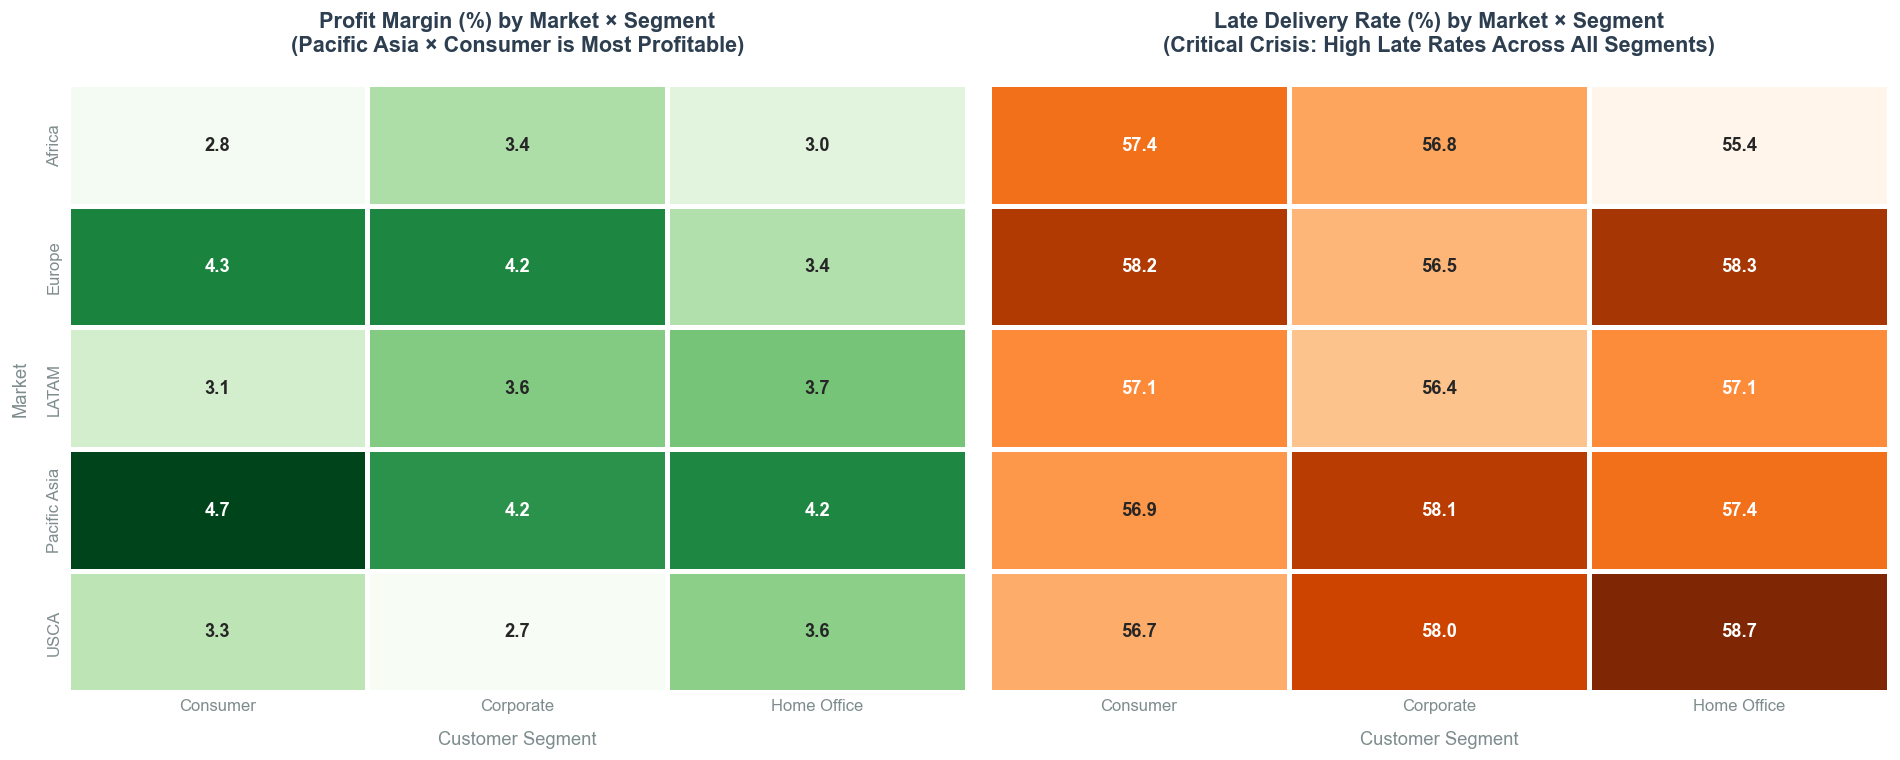

In [104]:
# ─── HEATMAP: Profit Margin & Late Delivery Rate (ENTERPRISE-GRADE) ──────────
pivot_pm = scorecard.pivot_table(values='profit_margin', index='Market', columns='Customer Segment')
pivot_lr = scorecard.pivot_table(values='late_delivery_rate', index='Market', columns='Customer Segment') * 100

# TỐI ƯU UI/UX: Sử dụng sharey=True để gộp chung trục dọc Market của 2 biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharey=True)

# 1. Heatmap Profit Margin
ax_pm = axes[0]
# cbar=False: Bỏ thanh màu để thiết kế gọn gàng, tập trung vào số liệu annot
sns.heatmap(pivot_pm, annot=True, fmt='.1f', cmap='Greens', ax=ax_pm,
            linewidths=2, linecolor='white', cbar=False,
            annot_kws={'fontsize': 11, 'weight': 'bold'})

ax_pm.set_title('Profit Margin (%) by Market × Segment\n(Pacific Asia × Consumer is Most Profitable)', 
                fontweight='bold', fontsize=13, color='#2C3E50', pad=20)
ax_pm.set_ylabel('Market', fontsize=11, color='#7F8C8D', labelpad=10)
ax_pm.set_xlabel('Customer Segment', fontsize=11, color='#7F8C8D', labelpad=10)
ax_pm.tick_params(axis='both', which='both', length=0, colors='#7F8C8D', labelsize=10)


# 2. Heatmap Late Delivery Rate
ax_lr = axes[1]
# cbar=False: Bỏ thanh màu. Dùng màu Oranges/Reds để nhấn mạnh tính cảnh báo rủi ro
sns.heatmap(pivot_lr, annot=True, fmt='.1f', cmap='Oranges', ax=ax_lr,
            linewidths=2, linecolor='white', cbar=False,
            annot_kws={'fontsize': 11, 'weight': 'bold'})

ax_lr.set_title('Late Delivery Rate (%) by Market × Segment\n(Critical Crisis: High Late Rates Across All Segments)', 
                fontweight='bold', fontsize=13, color='#2C3E50', pad=20)
ax_lr.set_xlabel('Customer Segment', fontsize=11, color='#7F8C8D', labelpad=10)

# TỐI ƯU UI/UX: Ẩn label trục Y của biểu đồ 2 vì đã dùng chung với biểu đồ 1
ax_lr.set_ylabel('') 
ax_lr.tick_params(axis='both', which='both', length=0, colors='#7F8C8D', labelsize=10)

# Căn chỉnh bố cục chặt chẽ, w_space nhỏ giúp 2 heatmap áp sát vào nhau như 1 widget tổng hợp
plt.subplots_adjust(wspace=0.08)
plt.tight_layout()
plt.show()

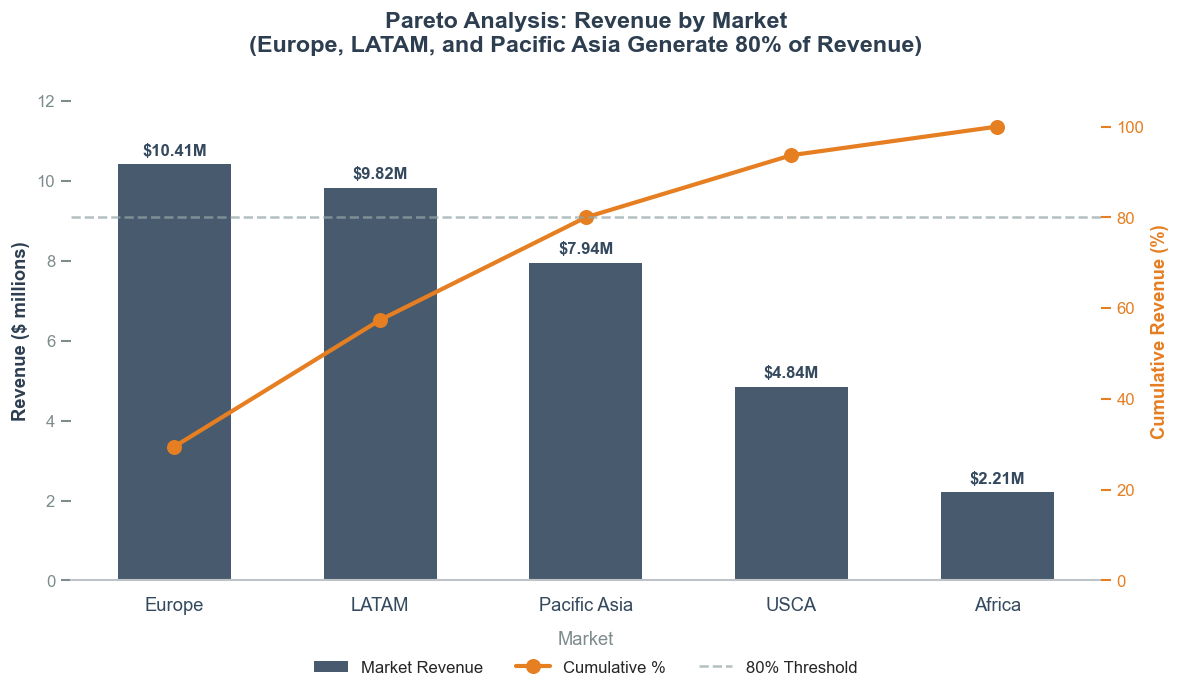

In [105]:
# ─── PARETO CHART: Revenue by Market ────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 6))

# Trục trái: Doanh thu cột dọc (Corporate Blue)
# THÊM: label='Market Revenue' để gộp vào Legend sau này
bars = ax1.bar(market_summary['Market'], market_summary['revenue'] / 1e6,
               color='#34495E', width=0.55, edgecolor='none', alpha=0.9, label='Market Revenue')

ax1.set_ylabel('Revenue ($ millions)', color='#2C3E50', fontsize=11, fontweight='semibold')
ax1.set_xlabel('Market', fontsize=11, color='#7F8C8D', labelpad=10)
ax1.tick_params(axis='y', colors='#7F8C8D', labelsize=10)
ax1.tick_params(axis='x', colors='#34495E', labelsize=11)

# Loại bỏ viền thừa của trục 1
for spine in ['top', 'left', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.spines['bottom'].set_color('#BDC3C7')

# Thêm nhãn số liệu trực tiếp trên cột
for bar, val in zip(bars, market_summary['revenue']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f'${val/1e6:.2f}M', ha='center', va='bottom', fontweight='bold', color='#34495E', fontsize=10)

# Trục phải: Tỷ lệ lũy kế (Muted Orange)
ax2 = ax1.twinx()
ax2.plot(market_summary['Market'], market_summary['cumulative_pct'],
         color='#E67E22', marker='o', linewidth=2.5, markersize=8, label='Cumulative %')
ax2.set_ylabel('Cumulative Revenue (%)', color='#E67E22', fontsize=11, fontweight='semibold')
ax2.tick_params(axis='y', colors='#E67E22', labelsize=10)

# Ngưỡng 80% (Pareto Line)
ax2.axhline(y=80, color='#95A5A6', linestyle='--', linewidth=1.5, alpha=0.7, label='80% Threshold')

# Loại bỏ viền cho trục 2
for spine in ['top', 'left', 'right', 'bottom']:
    ax2.spines[spine].set_visible(False)

# Nới giới hạn trục thoáng đãng
ax1.set_ylim(0, (market_summary['revenue'].max() / 1e6) * 1.2)
ax2.set_ylim(0, 110)

ax1.set_title('Pareto Analysis: Revenue by Market\n(Europe, LATAM, and Pacific Asia Generate 80% of Revenue)', 
             fontweight='bold', fontsize=14, color='#2C3E50', pad=18)

# ─── TỐI ƯU UI/UX: GỘP CHUNG LEGEND TỪ CẢ 2 TRỤC ──────────────────────────────
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# Đặt legend nằm ngang (ncol=3) ngay dưới biểu đồ một cách sạch sẽ
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center', 
           bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False, fontsize=10)

# Chống lỗi tràn chữ/mất legend khi lưu file
plt.tight_layout()
fig.subplots_adjust(bottom=0.18) 

plt.show()

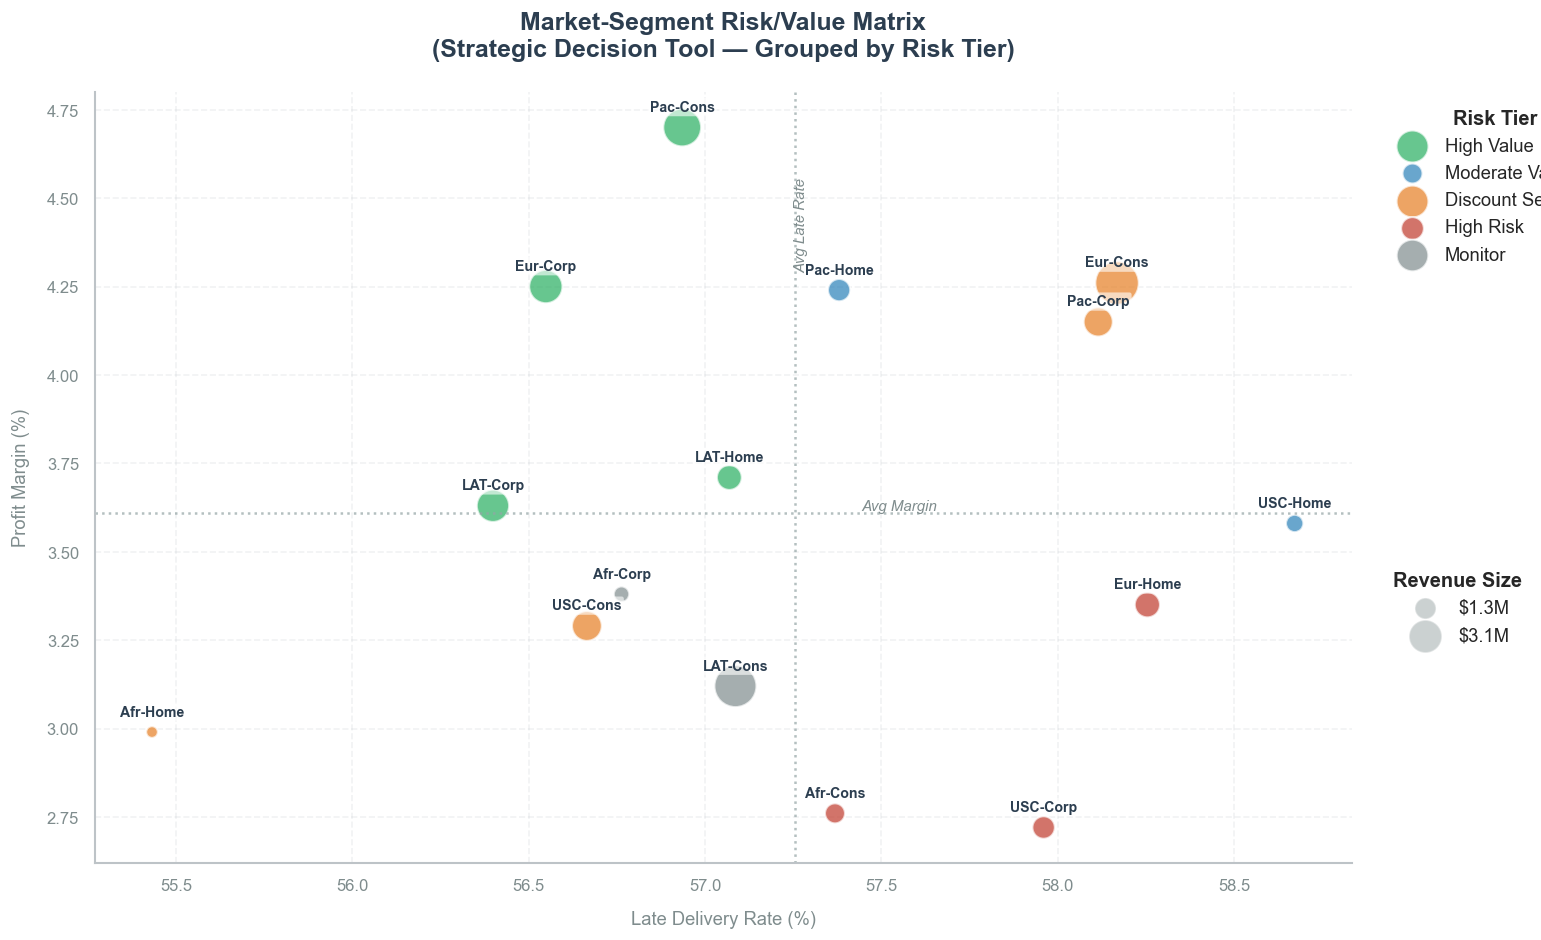

In [106]:
# ─── SEGMENT RISK/VALUE MATRIX ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))

tier_colors = {
    'High Value': '#27AE60', 
    'Moderate Value': '#2980B9',
    'Discount Sensitive': '#E67E22', 
    'High Risk': '#C0392B', 
    'Monitor': '#7F8C8D'
}

# Tính toán các giá trị trung bình để làm đường phân chia Ma trận
avg_late = (scorecard['late_delivery_rate'] * 100).mean()
avg_profit = scorecard['profit_margin'].mean()

# Vẽ các bong bóng dữ liệu
for tier, color in tier_colors.items():
    mask = scorecard['risk_tier'] == tier
    if mask.any():
        subset = scorecard[mask]
        ax.scatter(subset['late_delivery_rate'] * 100, subset['profit_margin'],
                   c=color, s=subset['revenue'] / 8e3, alpha=0.7,
                   label=tier, edgecolors='white', linewidths=1.2)
        
        # Thêm chú thích chữ với khung nền mờ (Bbox) để không bị rối nền Grid
        for _, row in subset.iterrows():
            ax.annotate(f"{row['Market'][:3]}-{row['Customer Segment'][:4]}",
                        (row['late_delivery_rate'] * 100, row['profit_margin']),
                        fontsize=8.5, ha='center', va='bottom', color='#2C3E50', fontweight='bold',
                        xytext=(0, 8), textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.6, ec='none'))

# ─── TỐI ƯU UI/UX 1: VẼ ĐƯỜNG PHÂN CHIA 4 GÓC MA TRẬN (QUADRANTS) ─────────────
ax.axhline(y=avg_profit, color='#95A5A6', linestyle=':', linewidth=1.5, alpha=0.7)
ax.axvline(x=avg_late, color='#95A5A6', linestyle=':', linewidth=1.5, alpha=0.7)

# Ghi chú thích nhỏ cho các đường ranh giới
ax.text(ax.get_xlim()[1]*0.98, avg_profit, 'Avg Margin', va='bottom', ha='right', color='#7F8C8D', fontsize=9, style='italic')
ax.text(avg_late, ax.get_ylim()[1]*0.95, 'Avg Late Rate', va='top', ha='left', color='#7F8C8D', fontsize=9, style='italic', rotation=90)


# Định dạng trục tọa độ phẳng, sạch sẽ
ax.set_xlabel('Late Delivery Rate (%)', fontsize=11, color='#7F8C8D', labelpad=10)
ax.set_ylabel('Profit Margin (%)', fontsize=11, color='#7F8C8D', labelpad=10)
ax.tick_params(colors='#7F8C8D', labelsize=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#BDC3C7')
ax.spines['bottom'].set_color('#BDC3C7')

ax.grid(True, linestyle='--', alpha=0.2, color='#BDC3C7')
ax.set_axisbelow(True)

ax.set_title('Market-Segment Risk/Value Matrix\n(Strategic Decision Tool — Grouped by Risk Tier)', 
             fontweight='bold', fontsize=15, color='#2C3E50', pad=22)


# ─── TỐI ƯU UI/UX 2: TẠO THANG ĐO KÍCH THƯỚC REVENUE CHO LEGEND ────────────────
# Lấy handles hiện tại (Color Legend)
handles, labels = ax.get_legend_handles_labels()

# Tự động tính toán 2 mốc doanh thu (Thấp - Cao) để làm mẫu kích thước trong Legend
rev_min, rev_max = scorecard['revenue'].min(), scorecard['revenue'].max()
rev_v1 = np.percentile(scorecard['revenue'], 25)
rev_v2 = np.percentile(scorecard['revenue'], 75)

# Tạo các handle rỗng chỉ để hiển thị kích thước bong bóng doanh thu
size_h1 = ax.scatter([], [], s=rev_v1 / 8e3, c='#7F8C8D', alpha=0.4, edgecolors='white')
size_h2 = ax.scatter([], [], s=rev_v2 / 8e3, c='#7F8C8D', alpha=0.4, edgecolors='white')

# Vẽ 2 bảng chú thích riêng biệt để nhìn không bị rối
first_legend = ax.legend(handles, labels, title='Risk Tier', bbox_to_anchor=(1.02, 1), 
                          loc='upper left', frameon=False, title_fontproperties={'weight':'bold'})
ax.add_artist(first_legend) # Giữ lại legend 1 khi vẽ legend 2

ax.legend([size_h1, size_h2], [f'${rev_v1/1e6:.1f}M', f'${rev_v2/1e6:.1f}M'], 
          title='Revenue Size', bbox_to_anchor=(1.02, 0.4), 
          loc='upper left', frameon=False, title_fontproperties={'weight':'bold'})

plt.tight_layout()
plt.show()

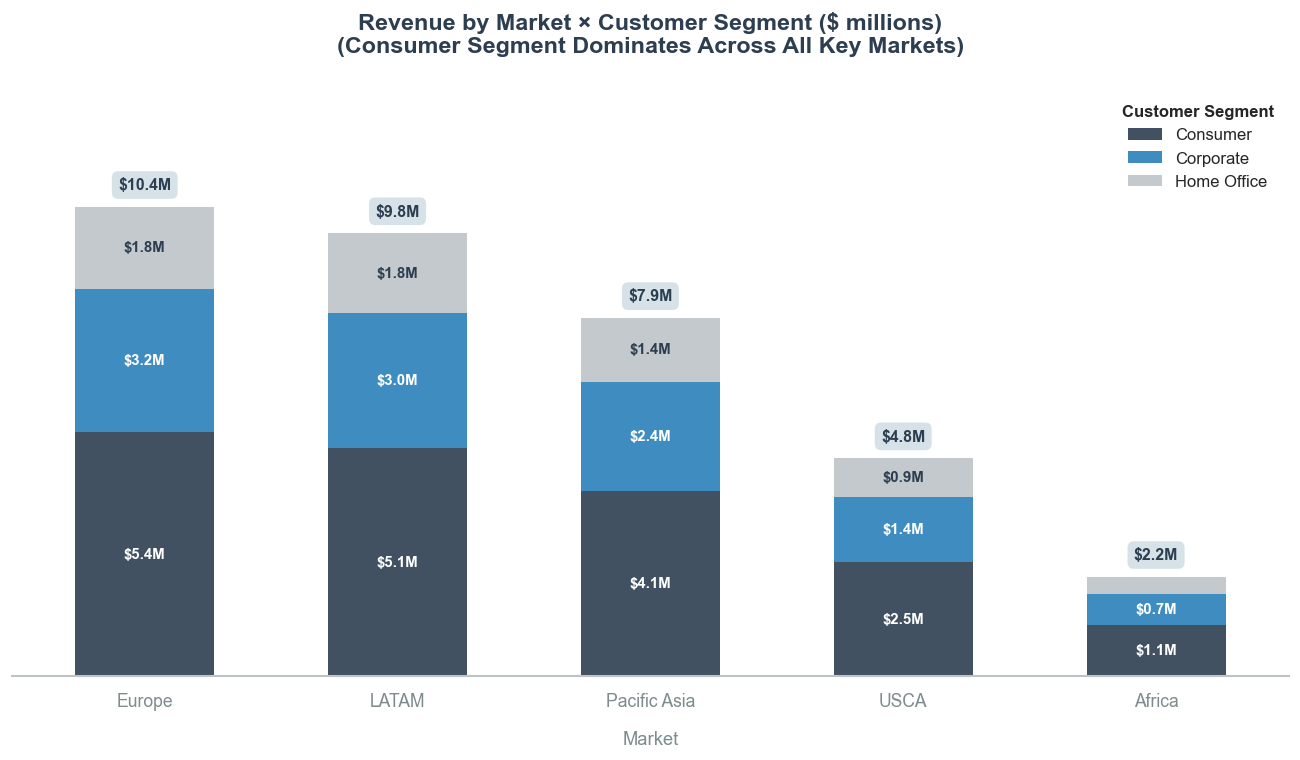

In [111]:
# ─── STACKED BAR: Revenue by Market × Segment ────────────────────────
pivot_rev = scorecard.pivot_table(values='revenue', index='Market', 
                                  columns='Customer Segment') / 1e6
pivot_rev = pivot_rev.reindex(market_summary['Market'])

fig, ax = plt.subplots(figsize=(11, 6.5))

colors = ['#2C3E50', '#2980B9', '#BDC3C7']
pivot_rev.plot(kind='bar', stacked=True, ax=ax,
               color=colors, edgecolor='none', width=0.55, alpha=0.9)

ax.set_title('Revenue by Market × Customer Segment ($ millions)\n(Consumer Segment Dominates Across All Key Markets)', 
             fontweight='bold', fontsize=14, color='#2C3E50', pad=22)
ax.set_xlabel('Market', fontsize=11, color='#7F8C8D', labelpad=12)
plt.xticks(rotation=0)

# Tính toán giá trị tổng
totals = pivot_rev.sum(axis=1)
max_total = totals.max()

# 1. HIỂN THỊ SỐ LIỆU TRONG TỪNG KHÚC CỘT
for i, container in enumerate(ax.containers):
    text_color = 'white' if i < 2 else '#2C3E50'
    labels = [f'${v:.1f}M' if v > (max_total * 0.05) else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type='center', 
                 color=text_color, fontweight='semibold', fontsize=9)

# 2. CHỈNH SỬA TẠI ĐÂY: HIỂN THỊ SỐ TỔNG DẠNG BADGE SẠCH SẼ
for rect, total in zip(ax.containers[-1].patches, totals):
    top_y = rect.get_y() + rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2, top_y + max_total * 0.03, 
            f'${total:.1f}M', ha='center', va='bottom', 
            fontweight='bold', color='#2C3E50', fontsize=9.5,
            bbox=dict(boxstyle='round,pad=0.4', fc="#D5E1E7", ec='none', alpha=0.95))

# TỐI ƯU UI/UX: XÓA SẠCH ĐƯỜNG DỌC & LƯỚI THỪA
ax.grid(False) 
ax.get_yaxis().set_visible(False) 
ax.tick_params(axis='x', colors='#7F8C8D', labelsize=10.5, bottom=False) 

for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#BDC3C7')

# Cấu hình Legend góc phải
ax.legend(title='Customer Segment', frameon=False, fontsize=10, 
          title_fontproperties={'weight':'bold', 'size':10}, loc='upper right')

# Nới rộng trục Y lên 1.25 để không gian phía trên các badge được thoải mái, không bị chạm viền ảnh
ax.set_ylim(0, max_total * 1.25)

plt.tight_layout()
plt.show()

### Save Output Contract Tables

In [113]:
# ═══ PHASE 1 OUTPUT CONTRACT ═══════════════════════════════════════
# Bảng 1: fraud_profile_order_level
print("📋 Phase 1 Output Contract:")
print(f"  1. fraud_profile_order_level: {len(fraud_profile)} rows ✅")

# Bảng 2: market_segment_scorecard
scorecard_export = scorecard[['Market', 'Customer Segment', 'revenue', 'order_count',
                              'profit_margin', 'late_delivery_rate', 'avg_discount_rate',
                              'risk_tier']].copy()

print(f"  2. market_segment_scorecard: {len(scorecard_export)} rows ✅")

# TỐI ƯU: Ép định dạng số gọn gàng khi hiển thị (Không đổi tên cột hay sửa data gốc)
display(scorecard_export.style.format({
    'revenue': lambda x: f"${x/1e6:.2f}M",          # Tự động chuyển số lớn thành dạng $X.XXM
    'order_count': '{:,}',                           # Thêm dấu phẩy hàng nghìn cho số lượng đơn
    'profit_margin': '{:.2f}%',                      # Gắn đuôi % cho biên lợi nhuận
    'late_delivery_rate': '{:.1%}',                  # Chuyển số thập phân sang %
    'avg_discount_rate': '{:.1%}'                    # Chuyển số thập phân sang %
}))

# Bảng 3: clean_baseline_df
print(f"  3. clean_baseline_df: {len(clean_df):,} rows ✅")
print(f"     Filter: Order Status NOT IN {excluded_status}")

📋 Phase 1 Output Contract:
  1. fraud_profile_order_level: 60 rows ✅
  2. market_segment_scorecard: 15 rows ✅


,Market,Customer Segment,revenue,order_count,profit_margin,late_delivery_rate,avg_discount_rate,risk_tier
0,Europe,Consumer,$5.42M,"9,220",4.26%,58.2%,10.2%,Discount Sensitive
1,LATAM,Consumer,$5.06M,"8,487",3.12%,57.1%,10.1%,Monitor
2,Pacific Asia,Consumer,$4.10M,"8,684",4.70%,56.9%,10.2%,High Value
3,Europe,Corporate,$3.17M,"5,380",4.25%,56.5%,10.1%,High Value
4,LATAM,Corporate,$3.00M,"4,946",3.63%,56.4%,10.2%,High Value
5,USCA,Consumer,$2.54M,"4,299",3.29%,56.7%,10.2%,Discount Sensitive
6,Pacific Asia,Corporate,$2.43M,"5,120",4.15%,58.1%,10.2%,Discount Sensitive
7,Europe,Home Office,$1.81M,"3,163",3.35%,58.3%,10.3%,High Risk
8,LATAM,Home Office,$1.77M,"2,981",3.71%,57.1%,10.1%,High Value
9,USCA,Corporate,$1.44M,"2,450",2.72%,58.0%,10.1%,High Risk


  3. clean_baseline_df: 172,765 rows ✅
     Filter: Order Status NOT IN ['CANCELED', 'SUSPECTED_FRAUD']


---
# 📋 Phase 1 — Summary & Conclusions

## Key Findings

### Fraud Analysis (P1)
- **Baseline fraud rate**: 2.26% (1,488 / 65,752 orders)
- **Critical finding**: 100% of fraud uses **TRANSFER** payment type (8.23% fraud rate)
- DEBIT, CASH, PAYMENT have **zero fraud** → strongest single rule
- Fraud is evenly spread across Markets and Customer Segments
- Discount rates show minimal difference between fraud and non-fraud orders

### Market Segmentation (P2)
- **Top 3 markets** (Europe + LATAM + Pacific Asia) = 80% of revenue
- **Highest profit margin**: Pacific Asia × Consumer (4.7%)
- **Highest risk**: Europe × Home Office (58.3% late delivery + 3.4% profit)
- Late delivery rate consistently high (55-59%) across all segments

## Recommendations
1. **TRANSFER payments** → mandatory enhanced verification
2. **Pacific Asia × Consumer** → prioritize for growth investment
3. **Europe × Home Office, USCA × Corporate** → address late delivery issues
4. **Use Market revenue share** as prior probabilities for Phase 3 contracts

## Ready for Phase 2
✅ `clean_baseline_df` created for Newsvendor demand estimation  
✅ Fraud handling rules defined for optimization models  
✅ Market priors established for two-stage contract scenarios